In [12]:
import pandas as pd

dataset = pd.read_csv('student_lifestyle_100k.csv')
dataset['Gender'] = dataset['Gender'].astype('category')
dataset['Department'] = dataset['Department'].astype('category')
dataset['Stress_Level'] = dataset['Stress_Level'].astype('category')

In [13]:
# Aufteilen nach True und False in der Spalte Depression
depressed = dataset[dataset['Depression']]
not_depressed = dataset[~dataset['Depression']]

# zufällige negative Stichproben ziehen (gleiche Anzahl wie positive Fälle)
not_depressed_sample = not_depressed.sample(n=len(depressed), random_state=42)

# Datensatz zusammensetzen
balanced_dataset = pd.concat([depressed, not_depressed_sample])

x = balanced_dataset.loc[:, 'Age':'Stress_Level']
y = balanced_dataset['Depression']

In [14]:
import torch

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, TargetEncoder
from torch.utils.data import TensorDataset, DataLoader

# Seed für Reproduzierbarkeit setzen
torch.manual_seed(42)
generator = torch.Generator().manual_seed(42) # für DataLoader-Shuffling

# Aufteilen in Training, Validierung und Test (60% Train, 20% Val, 20% Test)
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.4, random_state=42, stratify=y
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Spalten nach Typ trennen
target_encode_cols = ['Department']
onehot_cols = [c for c in x.select_dtypes(include='category').columns if c not in target_encode_cols]
numeric_cols = x.select_dtypes(include=['number', 'bool']).columns.tolist()

# Preprocessing-Transformer (numerisch: RobustScaler, kategorisch: OneHotEncoder, TargetEncoding für Department)
preprocessor = ColumnTransformer([
    ("numeric",     RobustScaler(),                           numeric_cols),
    ("onehot",      OneHotEncoder(drop='first', sparse_output=False), onehot_cols),
    ("target_enc",  TargetEncoder(target_type='binary', smooth='auto'), target_encode_cols),
])

# Fit-Transform auf Trainingsdaten, Transform auf Val-/Testdaten
x_train_scaled = preprocessor.fit_transform(x_train, y_train)
x_val_scaled = preprocessor.transform(x_val)
x_test_scaled = preprocessor.transform(x_test)

# setzen der neuen Feature-Anzahl nach Preprocessing
input_dim = x_train_scaled.shape[1]
output_dim = 1 # binäre Klassifikation (Depression ja/nein)


# Erstellen von DataLoadern für Training, Validierung und Test
batch_size = 128
train_loader = DataLoader(TensorDataset(torch.FloatTensor(x_train_scaled), torch.FloatTensor(y_train.values).view(-1, 1)), batch_size=batch_size, shuffle=True, generator=generator)
val_loader = DataLoader(TensorDataset(torch.FloatTensor(x_val_scaled), torch.FloatTensor(y_val.values).view(-1, 1)), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(x_test_scaled), torch.FloatTensor(y_test.values).view(-1, 1)), batch_size=batch_size, shuffle=False)

print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches per epoch: 95
Validation batches: 32
Test batches: 32


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=100,class_weight='balanced',n_jobs=-1,random_state=42)
rf.fit(x_train_scaled, y_train)

y_pred = rf.predict(x_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.66      0.73      0.70      2013
        True       0.70      0.63      0.66      2012

    accuracy                           0.68      4025
   macro avg       0.68      0.68      0.68      4025
weighted avg       0.68      0.68      0.68      4025



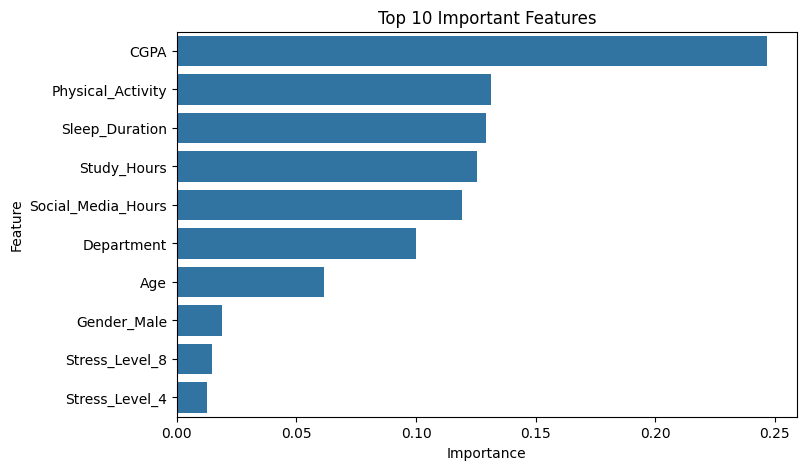

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
features = preprocessor.get_feature_names_out()
features = [f.split('__')[-1] for f in features]

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
plt.title("Top 10 Important Features")
plt.show()

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}
grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)
grid.fit(x_train_scaled, y_train)
best_model = grid.best_estimator_

In [20]:
final_pred = best_model.predict(x_test_scaled)
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

       False       0.67      0.74      0.71      2013
        True       0.71      0.64      0.67      2012

    accuracy                           0.69      4025
   macro avg       0.69      0.69      0.69      4025
weighted avg       0.69      0.69      0.69      4025

